# Masters Thesis : **Towards Domain-General DeepFake classification: A Dual-Branch Frequency and Spatial Approach with Few-Shot Adaptation.**

In [43]:
# importing needed libraries for this project
import torch
import os
import torch
from sklearn.manifold import TSNE
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import numpy as np
try:
    from facenet_pytorch import MTCNN
except ImportError:
    MTCNN = None
from collections import defaultdict

In [44]:
"""
Custom Dataser class to handle the image inputs. 
Face crop are done by using MTCNN.
"""

class DeepfakeDataset(Dataset):
    def __init__(self, root_directory, spatial_transform=None, fd_transform=None):
        self.dataset = datasets.ImageFolder(
            root=root_directory, transform=spatial_transform) 
        self.root_directory = root_directory 
        self.freq_domain_transform = fd_transform
        self.mtcnn = MTCNN(image_size=224, margin=20,
                           device=DEVICE) if MTCNN else None 
        print(
            f"Mapping of the class : {root_directory}:", self.dataset.class_to_idx)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, i):
        im_path, label = self.dataset.samples[i]
        im = Image.open(im_path).convert('RGB')
        if self.mtcnn:
            im_crop = self.mtcnn(im)
            if im_crop is None:
                im_crop = self.dataset.transform(im)
        else:
            image_cropped = self.dataset.transform(im)

        fd_img = compute_fd_input(self.freq_domain_transform(im))
        return im_crop, fd_img, torch.tensor(label, dtype=torch.float)

In [45]:
"""
Compute the frequency domain. 
"""
def compute_fd_input(img_tensor, mask_ratio=0.5, radius=10):
    Ht, Wth = img_tensor.shape[-2:]
    a, b = torch.meshgrid(torch.arange(Ht), torch.arange(Wth), indexing='ij')
    a = a.to(img_tensor.device)
    b = b.to(img_tensor.device)
    a_center = Ht // 2
    b_center = Wth // 2
    
    # Filter - High pass
    mask = ((a - a_center) ** 2 + (b - b_center) ** 2 > radius ** 2).float()
    fft = torch.fft.fft2(img_tensor)
    shitted_fft  = torch.fft.fftshift(fft)
    filtered_fft = shitted_fft * mask

    mgt = torch.abs(filtered_fft)
    phase = torch.angle(filtered_fft)

    # Masking frequency domain
    if mask_ratio > 0:
        mask = torch.rand(
            mgt.shape, device=mgt.device) > mask_ratio
        masked_magnitude = mgt * mask
    else:
        masked_magnitude = mgt

    masked_fft = masked_magnitude * torch.exp(1j * phase)
    return torch.log1p(masked_magnitude)

In [46]:
"""
Frequency domain feature extractor module by using ResNet18 as a backbone.
"""

class FrequencyDomainClassifier(nn.Module):
    def __init__(self):
        super(FrequencyDomainClassifier, self).__init__()
        self.resnet = models.resnet18(pretrained=True) 
        self.resnet.conv1 = nn.Conv2d(
            3, 
            64, 
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)
        self.dropout = nn.Dropout(0.7)

    def forward(self, x):
        features = self.resnet(x)
        features = self.dropout(features)
        return features

In [47]:
"""
Spatial domain feature extractor module by using pretrained Swin Transformer as a backbone.

"""

class SpatialDomainClassifier(nn.Module):
    def __init__(self):
        super(SpatialDomainClassifier, self).__init__()
        self.swin_t = models.swin_t(weights='IMAGENET1K_V1') 
        for param in self.swin_t.parameters():
            param.requires_grad = False
        for param in self.swswin_tin.features[-4:].parameters():
            param.requires_grad = True
        self.swin_t.head = nn.Identity()
        self.fc = nn.Linear(768, 128)
        self.dropout = nn.Dropout(0.7)

    def forward(self, x):
        features = self.swin_t(x)
        features = F.relu(self.fc(features))
        features = self.dropout(features)
        return features

In [48]:
"""
Defining the cross attention fusion module to fuse the features from both branches.
"""
class CrossAttentionFusion(nn.Module):
    def __init__(self, feature_dim=128, num_heads=4):
        super(CrossAttentionFusion, self).__init__()
        self.multihead_attention = nn.MultiheadAttention(
            embed_dim=feature_dim, num_heads=num_heads)
        self.norm = nn.LayerNorm(feature_dim)

    def forward(self, frequrncy_domain_features, spatial_features):
        frequrncy_domain_features = frequrncy_domain_features.unsqueeze(0)
        spatial_features = spatial_features.unsqueeze(0)
        fused_features, attention_weights = self.multihead_attention(
            spatial_features, frequrncy_domain_features, frequrncy_domain_features)
        fused_features = fused_features.squeeze(
            0) + spatial_features.squeeze(0)
        fused_features = self.norm(fused_features)
        return fused_features, attention_weights

In [49]:
"""
Defining the concatenation fusion module to fuse the features from both branches.
"""

class ConcatFusion(nn.Module):
    def __init__(self, feature_dim=128):
        super(ConcatFusion, self).__init__()
        self.fully_connect = nn.Linear(feature_dim * 2, feature_dim)
        self.norm = nn.LayerNorm(feature_dim)

    def forward(self, frequrncy_domain_features, spatial_features):
        fused_features = torch.cat(
            (frequrncy_domain_features, spatial_features), dim=-1)
        fused_features = F.relu(self.fully_connect(fused_features))
        fused_features = self.norm(fused_features)
        return fused_features, None

In [50]:
"""
dual branch model, including frequency domain and spatial domain. 
"""

class TwoBranchModel(nn.Module):
    def __init__(self, use_cross_attention=True):
        super(TwoBranchModel, self).__init__()
        self.frequency_domain_branch = FrequencyDomainClassifier()
        self.spatial_branch = SpatialDomainClassifier()
        self.use_cross_attention = use_cross_attention
        self.fusion = CrossAttentionFusion(
            feature_dim=128) if use_cross_attention else ConcatFusion(feature_dim=128)
        self.classifier_head = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, spatial_feature, freq_domain_feature):
        fd_features = self.frequency_domain_branch(freq_domain_feature)
        spatial_features = self.spatial_branch(spatial_feature)
        fused_features, attention_weights = self.fusion(
            fd_features, spatial_features)
        logits = self.classifier_head(fused_features)
        return logits, fd_features, spatial_features, attention_weights

In [51]:
def attention_regularization(attention_weights):
    if attention_weights is None:
        return 0.0
    return torch.mean(torch.abs(attention_weights - 1.0 / attention_weights.size(-1)))

In [52]:
"""
Supervised Learning with early stopping
"""

def train_supervised(model, train_loader, test_loader, optimizer, scheduler, device, MODEL_SAVE_PATH, epochs=50, patience=5):
    criterion = nn.BCEWithLogitsLoss()
    best_test_accuracy = 0.0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for spatial_images, freq_domain_images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            spatial_images, freq_domain_images, labels = spatial_images.to(
                device), freq_domain_images.to(device), labels.to(device).float()
            optimizer.zero_grad()
            logits, _, _, attention_weights = model(
                spatial_images, freq_domain_images)
            loss = criterion(logits.squeeze(), labels) + 0.1 * \
                attention_regularization(attention_weights)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            predictions = (torch.sigmoid(logits.squeeze()) > 0.5).float()
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

        scheduler.step()
        train_accuracy = train_correct / train_total
        train_loss /= len(train_loader)

        # Test evaluation (used as validation)
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for spatial_images, freq_domain_images, labels in test_loader:
                spatial_images, freq_domain_images, labels = spatial_images.to(
                    device), freq_domain_images.to(device), labels.to(device).float()
                logits, _, _, _ = model(spatial_images, freq_domain_images)
                loss = criterion(logits.squeeze(), labels)
                test_loss += loss.item()
                predictions = (torch.sigmoid(logits.squeeze()) > 0.5).float()
                test_correct += (predictions == labels).sum().item()
                test_total += labels.size(0)

        test_accuracy = test_correct / test_total
        test_loss /= len(test_loader)
        print(f"Epoch {epoch+1}: Train Loss - {train_loss:.4f}, Train Acc - {train_accuracy:.4f}, Test Loss - {test_loss:.4f}, Test Acc - {test_accuracy:.4f}")

        # Early stopping
        if test_accuracy > best_test_accuracy:
            best_test_accuracy = test_accuracy
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping happened after {epoch+1} epochs")
                break

In [53]:
""" 
Evaluating model
"""

def evaluate_model(model, test_loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for spatial_images, frequency_domain_images, labels in tqdm(test_loader, desc="Evaluating"):
            spatial_images, frequency_domain_images, labels = spatial_images.to(
                device), frequency_domain_images.to(device), labels.to(device)
            logits, _, _, _ = model(spatial_images, frequency_domain_images)
            logits = logits.squeeze()
            probability = torch.sigmoid(logits)
            predictions = (probability > 0.5).float()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())
            y_prob.extend(probability.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    eer = (fp / (fp + tn) + fn / (fn + tp)) / \
        2 if (fp + tn) > 0 and (fn + tp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    print(f"\nTest Accuracy : {accuracy*100:.2f}%")
    print(f"AUC-ROC: {auc:.4f}, EER: {eer:.4f}, F1-Score: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))

    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fake", "Real"],
                yticklabels=["Fake", "Real"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy, auc, eer, f1, y_true, y_pred

In [54]:
"""
t-SNE Visualisation
"""
def visualise_tsne(model, test_loader, device):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for spatial_images, frequency_domain_images, labels in test_loader:
            spatial_images, frequency_domain_images = spatial_images.to(
                device), frequency_domain_images.to(device)
            _, frequency_domain_features, spatial_features, _ = model(
                spatial_images, frequency_domain_images)
            fused_features, _ = model.fusion(
                frequency_domain_features, spatial_features)
            features.append(fused_features.cpu().numpy())
            labels.append(labels.numpy())
    features = np.concatenate(features)
    labels = np.concatenate(labels)
    tsne = TSNE(n_components=2, random_state=42)
    tsne_features = tsne.fit_transform(features)
    plt.scatter(tsne_features[labels == 0, 0],
                tsne_features[labels == 0, 1], label="Fake")
    plt.scatter(tsne_features[labels == 1, 0],
                tsne_features[labels == 1, 1], label="Real")
    plt.legend()
    plt.title("t-SNE of Fused Features")
    plt.show()

In [55]:
"""
Testing on random images
"""

def test_random_images(model, test_dir=None, test_dataset=None, num_images=5, device="cpu", spatial_transform=None, fd_transform=None):
    model.eval()
    predictions = []

    if test_dir:
        image_files = []
        for root, _, files in os.walk(test_dir):
            image_files.extend([os.path.join(root, f)
                               for f in files if f.endswith(('.png', '.jpg', '.jpeg'))])
        selected_files = random.sample(
            image_files, min(num_images, len(image_files)))

        mtcnn = MTCNN(image_size=224, margin=20,
                      device=device) if MTCNN else None
        with torch.no_grad():
            for image_path in selected_files:
                image = Image.open(image_path).convert('RGB')
                if mtcnn:
                    image_cropped = mtcnn(image)
                    if image_cropped is None:
                        image_cropped = spatial_transform(image)
                else:
                    image_cropped = spatial_transform(image)
                spatial_img = image_cropped.unsqueeze(0)
                frequency_domain_img = compute_fd_input(fd_transform(image)).unsqueeze(0)

                spatial_img, frequency_domain_img = spatial_img.to(
                    device), frequency_domain_img.to(device)
                logits, _, _, _ = model(spatial_img, frequency_domain_img)
                prob = torch.sigmoid(logits).item()
                pred = "Real" if prob > 0.5 else "Fake"
                confidence = prob if prob > 0.5 else 1 - prob
                predictions.append((image_path, pred, confidence))
                print(
                    f"Image: {os.path.basename(image_path)}, Prediction: {pred}, Confidence: {confidence:.4f}")

    elif test_dataset:
        indices = random.sample(range(len(test_dataset)),
                                min(num_images, len(test_dataset)))
        with torch.no_grad():
            for idx in indices:
                spatial_img, frequency_domain_img, label = test_dataset[idx]
                spatial_img, frequency_domain_img = spatial_img.unsqueeze(
                    0).to(device), frequency_domain_img.unsqueeze(0).to(device)
                logits, _, _, _ = model(spatial_img, frequency_domain_img)
                prob = torch.sigmoid(logits).item()
                pred = "Real" if prob > 0.5 else "Fake"
                confidence = prob if prob > 0.5 else 1 - prob
                true_label = "Real" if label == 1 else "Fake"
                predictions.append((idx, pred, confidence, true_label))
                print(
                    f"Test Image #{idx}, Prediction: {pred}, Confidence: {confidence:.4f}, True Label: {true_label}")

    return predictions

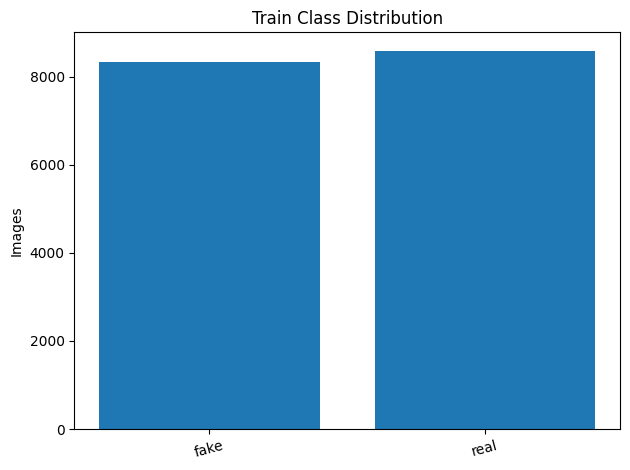

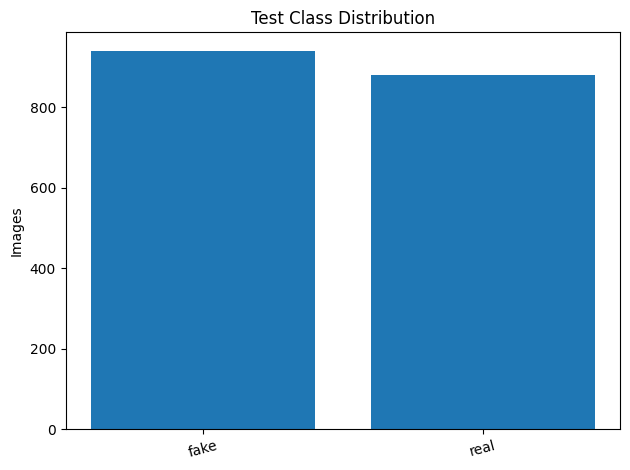

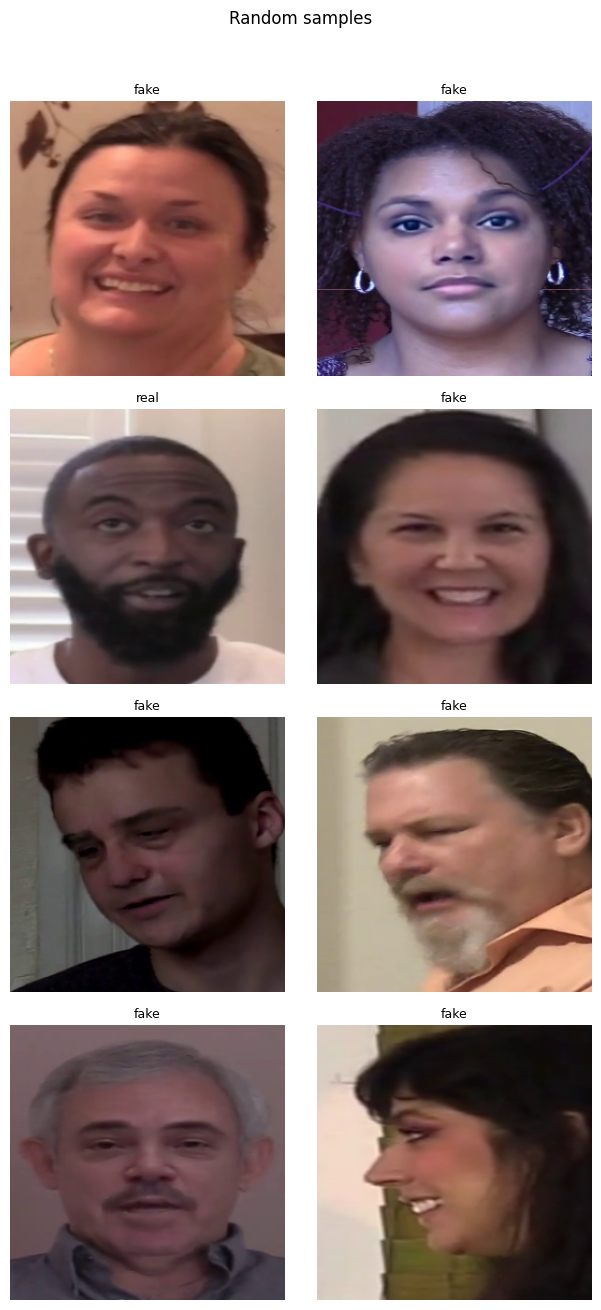

In [56]:
"""
Visualisation of test and training dataset distribution
"""

def _load_imagefolder(dir_path: str):
    if not os.path.isdir(dir_path):
        raise ValueError(f"No Directory Found: {dir_path}")
    ds = datasets.ImageFolder(root=dir_path, transform=None) #transformation not needed for visualisation
    if len(ds.samples) == 0:
        raise ValueError(
            f"Image not found : {dir_path} ")
    index_to_class = {v: k for k, v in ds.class_to_idx.items()}
    return ds.samples, index_to_class


def plot_class_balance_from_dir(dir_path: str, title: str = "Class Balance"):
    """
    Count images per class
    """
    samples, index_to_class = _load_imagefolder(dir_path)
    labels = [lbl for _, lbl in samples]
    counts = Counter(labels)

    # Order bars by label index so class order is stable
    label_indices = sorted(counts.keys())
    class_names = [index_to_class[i] for i in label_indices]
    values = [counts[i] for i in label_indices]

    plt.figure()
    plt.bar(class_names, values)
    plt.title(title)
    plt.ylabel("Images")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


def show_samples_from_dir(dir_path: str, n: int = 8, seed: int = 42):
    """
    Show a grid of n random images from an ImageFolder directory.
    """
    random.seed(seed)
    samples, index_to_class = _load_imagefolder(dir_path)

    n = min(n, len(samples))  # avoid sampling more than available
    picked = random.sample(samples, n)

    cols = max(2, int(n**0.5)) # defining a square grid.
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(3.2*cols, 3.2*rows))
    for i, (img_path, lbl_idx) in enumerate(picked, 1):
        img = Image.open(img_path).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(index_to_class[lbl_idx], fontsize=9)
    plt.suptitle("Random samples", y=1.02)
    plt.tight_layout()
    plt.show()


train_dir = "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFDC_trained"
test_dir = "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/test_frames_modified"

plot_class_balance_from_dir(train_dir, "Train Class Distribution")
plot_class_balance_from_dir(test_dir,  "Test Class Distribution")
show_samples_from_dir(train_dir, n=8)

In [ ]:

#Main
if __name__ == "__main__":
    TRAIN_DATA_PATH = "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFDC_trained"
    TEST_DATA_PATH = "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/test_frames_modified"
    TEST_DIR = None  
    BATCH_SIZE = 32
    NUM_TEST_IMAGES = 5

    #checking GPU
    if torch.backends.mps.is_available():
        DEVICE = torch.device("mps")
    else:
        DEVICE = torch.device("cpu")

    # Spatial transforms
    spatial_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomCrop(224, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[
                             0.229, 0.224, 0.225])
    ])
    # Frequency domain transforms
    fd_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[
                             0.229, 0.224, 0.225])
    ])

    # Loading datasets
    train_dataset = DeepfakeDataset(
        TRAIN_DATA_PATH, spatial_transform=spatial_transform, fd_transform=fd_transform)
    test_dataset = DeepfakeDataset(
        TEST_DATA_PATH, spatial_transform=spatial_transform, fd_transform=fd_transform)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Class-to-index mapping for /Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFDC_trained: {'fake': 0, 'real': 1}
Class-to-index mapping for /Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/test_frames_modified: {'fake': 0, 'real': 1}


In [ ]:
# Concatenation Fusion Model Training

print("\nTraining Concatenation Model:")
model_concat = TwoBranchModel(use_cross_attention=False).to(DEVICE)
optimizer_concat = torch.optim.Adam(model_concat.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_concat = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_concat, T_max=50)
train_supervised(model_concat,
                 train_loader,
                 test_loader,
                 optimizer_concat,
                 scheduler_concat,
                 DEVICE,
                 MODEL_SAVE_PATH="/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/kova02_concat_26_9.pth",
                 epochs=50,
                 patience=5)



Training Concatenation Model:


Epoch 1/50: 100%|██████████| 529/529 [11:00<00:00,  1.25s/it]


Epoch 1: Train Loss: 0.6955, Train Acc: 0.5063, Test Loss: 0.6878, Test Acc: 0.5666


Epoch 2/50: 100%|██████████| 529/529 [10:31<00:00,  1.19s/it]


Epoch 2: Train Loss: 0.6919, Train Acc: 0.5236, Test Loss: 0.6932, Test Acc: 0.5440


...

Epoch 10: Train Loss: 0.6701, Train Acc: 0.5905, Test Loss: 0.6576, Test Acc: 0.6144


Epoch 11/50: 100%|██████████| 529/529 [09:34<00:00,  1.09s/it]


Epoch 11: Train Loss: 0.6665, Train Acc: 0.5929, Test Loss: 0.6700, Test Acc: 0.5792


Epoch 12/50:  79%|███████▉  | 418/529 [07:30<01:59,  1.08s/it]


KeyboardInterrupt: 


Evaluating Concatenation Model on Test Dataset:


Evaluating: 100%|██████████| 57/57 [01:00<00:00,  1.06s/it]



Test Accuracy: 60.01%
AUC-ROC: 0.6434, EER: 0.4057, F1-Score: 0.5024
              precision    recall  f1-score   support

        Fake       0.59      0.77      0.67       939
        Real       0.63      0.42      0.50       879

    accuracy                           0.60      1818
   macro avg       0.61      0.59      0.58      1818
weighted avg       0.61      0.60      0.59      1818



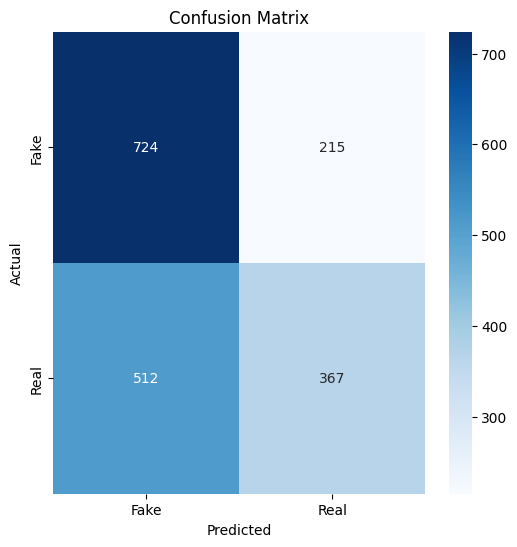


Visualizing t-SNE (Concatenation):


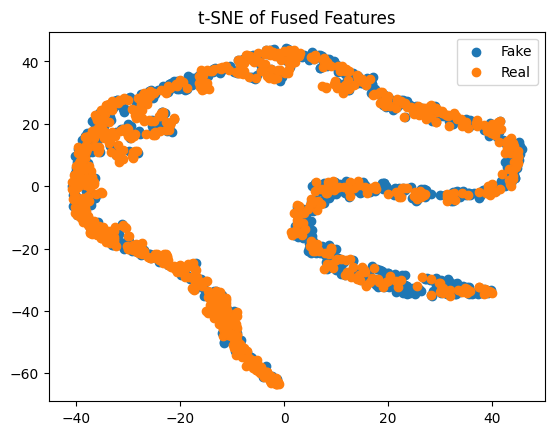

In [ ]:
# Evaluating Concatenation Model on Test Dataset

print("\nEvaluating Concatenation Model on Test Dataset:")
acc, auc, eer, f1, y_true_concat, y_pred_concat = evaluate_model(model_concat, test_loader, DEVICE)

In [ ]:
# t-SNE Visualisation on Concatenation fusion Model
print("\nVisualising t-SNE (Concatenation):")
visualise_tsne(model_concat, test_loader, DEVICE)

Real: /Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFDC_trained/real/ersbqxgktr_5_231.png
Fake: /Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFDC_trained/fake/bcpzcqbwcv_5_279.png


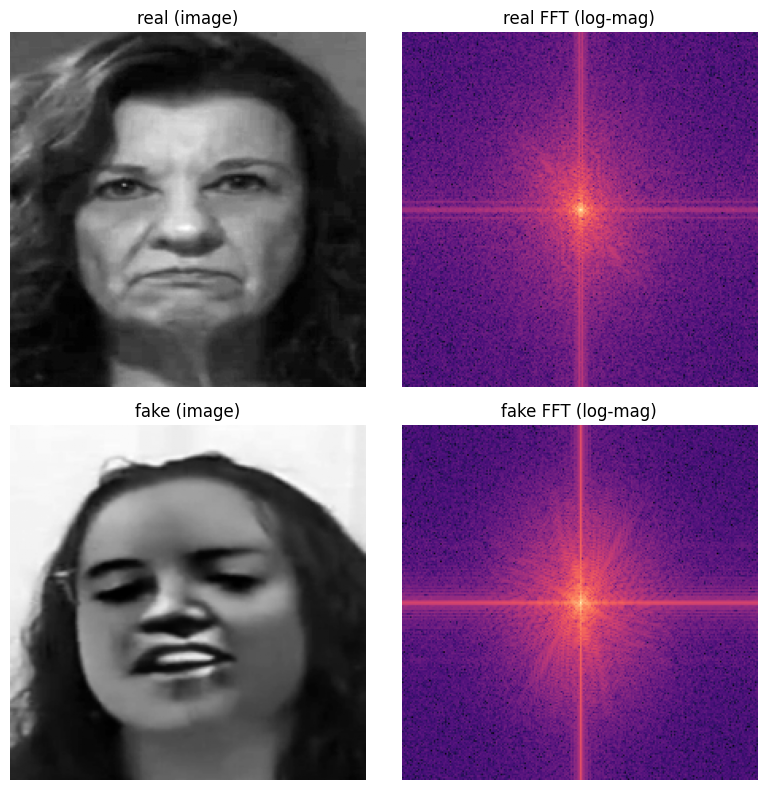

In [28]:
""" 
Visualisation frequency domain for real and fake images
"""

def _pick_class(by_class, target):
    # picking the classes
    t = target.lower()
    for c in by_class:
        if c.lower() == t:
            return c
    for c in by_class:
        if t in c.lower():
            return c
    return None


def _fft_logmag(img_array_2d):
    #Caluculating the FFT and log magnitude
    F = np.fft.fft2(img_array_2d.astype(np.float32))
    F = np.fft.fftshift(F)
    mag = np.log1p(np.abs(F))
    return mag


def visualise_real_fake_fft(
    dir_path: str,
    real_name: str = "real",
    fake_name: str = "fake",
    size=(224, 224),
    grayscale: bool = True,
    seed: int = 42,
    save_path: str = None
):
    random.seed(seed)

    # Load as ImageFolder to discover class folders
    ds = datasets.ImageFolder(root=dir_path, transform=None)
    if len(ds.samples) == 0:
        raise ValueError(f"No images found under: {dir_path}")

    idx_to_class = {v: k for k, v in ds.class_to_idx.items()}
    by_class = defaultdict(list)
    for path, lbl in ds.samples:
        by_class[idx_to_class[lbl]].append(path)

    real_cls = _pick_class(by_class, real_name)
    fake_cls = _pick_class(by_class, fake_name)
    if (real_cls is None) or (fake_cls is None) or (real_cls == fake_cls):
        classes = sorted(by_class.keys())
        real_cls, fake_cls = classes[0], classes[1]

    # One image per class
    real_img_path = random.choice(by_class[real_cls])
    fake_img_path = random.choice(by_class[fake_cls])
    print(f"Real: {real_img_path}\nFake: {fake_img_path}")

    # Preprocess
    def load_im(path):
        im = Image.open(path).convert("RGB")
        im = im.resize(size, Image.BILINEAR)
        return im

    real_img = load_im(real_img_path)
    fake_img = load_im(fake_img_path)

    # Setting up the plots 
    if grayscale:
        rL = np.asarray(real_img.convert("L"))
        fL = np.asarray(fake_img.convert("L"))
        r_mag = _fft_logmag(rL)
        f_mag = _fft_logmag(fL)

        fig, axs = plt.subplots(2, 2, figsize=(8, 8))
        axs[0, 0].imshow(rL, cmap="gray")
        axs[0, 0].set_title(f"{real_cls} (image)")
        axs[0, 0].axis("off")
        axs[0, 1].imshow(r_mag, cmap="magma")
        axs[0, 1].set_title(f"{real_cls} FFT (log-mag)")
        axs[0, 1].axis("off")
        axs[1, 0].imshow(fL, cmap="gray")
        axs[1, 0].set_title(f"{fake_cls} (image)")
        axs[1, 0].axis("off")
        axs[1, 1].imshow(f_mag, cmap="magma")
        axs[1, 1].set_title(f"{fake_cls} FFT (log-mag)")
        axs[1, 1].axis("off")
        plt.tight_layout()


train_dir = "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFDC_trained"
visualise_real_fake_fft(train_dir, grayscale=True)

In [ ]:
"""
Cross Attention Fusion Model Training.
"""
print("\nTraining Cross Attention Model:")
model_cross = TwoBranchModel(use_cross_attention=True).to(DEVICE)
optimizer_cross = torch.optim.Adam(
    model_cross.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_cross = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cross, T_max=50)
train_supervised(model_cross,
                 train_loader,
                 test_loader,
                 optimizer_cross,
                 scheduler_cross,
                 DEVICE,
                 MODEL_SAVE_PATH="/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/kova02_cross_26_9.pth",
                 epochs=50,
                 patience=5)




Training Concatenation Model:


/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50: 100%|██████████| 529/529 [13:07<00:00,  1.49s/it]


Epoch 1: Train Loss: 0.6942, Train Acc: 0.5087, Test Loss: 0.6875, Test Acc: 0.5583


Epoch 2/50: 100%|██████████| 529/529 [10:24<00:00,  1.18s/it]


Epoch 2: Train Loss: 0.6896, Train Acc: 0.5354, Test Loss: 0.7042, Test Acc: 0.5418


...

Epoch 7: Train Loss: 0.6738, Train Acc: 0.5854, Test Loss: 0.6707, Test Acc: 0.5853


Epoch 8/50: 100%|██████████| 529/529 [09:56<00:00,  1.13s/it]


Epoch 8: Train Loss: 0.6698, Train Acc: 0.5924, Test Loss: 0.6589, Test Acc: 0.6051


Epoch 9/50:  71%|███████▏  | 377/529 [07:26<03:00,  1.19s/it]


KeyboardInterrupt: 


Evaluating Cross attention fusion Model on test :


Evaluating: 100%|██████████| 57/57 [01:06<00:00,  1.17s/it]



Test Accuracy: 61.33%
AUC-ROC: 0.6481, EER: 0.3923, F1-Score: 0.5234
              precision    recall  f1-score   support

        Fake       0.60      0.78      0.67       939
        Real       0.65      0.44      0.52       879

    accuracy                           0.61      1818
   macro avg       0.62      0.61      0.60      1818
weighted avg       0.62      0.61      0.60      1818



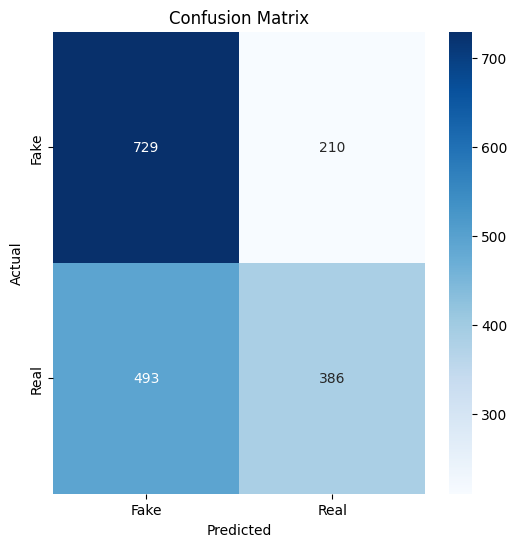


Visualising t-SNE (Cross attention fusion):


NameError: name 'visualise_tsne' is not defined

In [ ]:
""" 
Evaluating the cross attention fusion model
Visualising the t-SNE
"""
print("\nEvaluating Cross attention fusion Model on test :")
acc, auc, eer, f1, y_true_cross, y_pred_cross = evaluate_model(
    model_concat, test_loader, DEVICE)
print("\nVisualising t-SNE (Cross attention fusion):")
visualise_tsne(model_concat, test_loader, DEVICE)

In [ ]:
"""
Frequrncy Domain Only Model. 
"""
class FDBranchModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = FrequencyDomainClassifier()  # outputs 128d feature vector
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, fd_x):
        feats = self.encoder(fd_x)
        logits = self.classifier(feats)
        return logits, feats

In [ ]:
""" 
Spatial Domain Only Model

"""
class SpatialBranchModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SpatialDomainClassifier()  # outputs 128d features vectors 
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, spatial_x):
        feats = self.encoder(spatial_x)
        logits = self.classifier(feats)
        return logits, feats

In [ ]:
"""
Defining training function with single branch input.
"""
def train_single_input(model, train_loader, test_loader, optimizer, scheduler, device,
                       MODEL_SAVE_PATH, epochs=50, patience=5, input_kind="fd"):
    criterion = nn.BCEWithLogitsLoss()
    best_test_acc, patience_counter = 0.0, 0

    # Training loop
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        # Processing bar for each epoch
        for spatial_images, fd_images, labels in tqdm(train_loader, desc=f"[{input_kind.upper()}] Epoch {epoch+1}/{epochs}"):
            x = fd_images if input_kind == "fd" else spatial_images
            x, labels = x.to(device), labels.to(device).float()

            optimizer.zero_grad()
            logits, _ = model(x)
            loss = criterion(logits.squeeze(), labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = (torch.sigmoid(logits.squeeze()) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        train_loss = running_loss / max(1, len(train_loader))
        train_acc = correct / max(1, total)

        # Evaluating on test set
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for spatial_images, fd_images, labels in test_loader:
                x = fd_images if input_kind == "fd" else spatial_images
                x, labels = x.to(device), labels.to(device).float()
                logits, _ = model(x)
                loss = criterion(logits.squeeze(), labels)

                running_loss += loss.item()
                preds = (torch.sigmoid(logits.squeeze()) > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        test_loss = running_loss / max(1, len(test_loader))
        test_acc = correct / max(1, total)

        print(f"[{input_kind.upper()}] Epoch {epoch+1}: "
              f"Train Loss {train_loss:.4f} -- Train Acc {train_acc:.4f} | "
              f"Test Loss {test_loss:.4f} -- Test Acc {test_acc:.4f}")

        # Early stopping Wwith 5 patience
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"[{input_kind.upper()}] Early stopping at epoch {epoch+1}")
                break

In [ ]:
"""
Defining Evaluation function with single branch input.

"""
def evaluate_single_input(model, test_loader, device, input_kind="fd"):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for spatial_images, fd_images, labels in tqdm(test_loader, desc=f"Evaluating ({input_kind})"):
            x = fd_images if input_kind == "fd" else spatial_images
            x = x.to(device)
            labels = labels.to(device)
            logits, _ = model(x)
            logits = logits.squeeze()
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    eer = (fp / (fp + tn) + fn / (fn + tp)) / \
        2 if (fp + tn) > 0 and (fn + tp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    print(f"\n[{input_kind.upper()}] Test Accuracy: {acc*100:.2f}%")
    print(
        f"[{input_kind.upper()}] AUC-ROC: {auc:.4f}, EER: {eer:.4f}, F1-Score: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))

    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"[{input_kind.upper()}] Confusion Matrix")
    plt.show()

    return acc, auc, eer, f1


Training FD-only model:


/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[FD] Epoch 1/50: 100%|██████████| 529/529 [04:51<00:00,  1.81it/s]


[FD] Epoch 1: Train Loss 0.6974 | Train Acc 0.5183 | Test Loss 0.6856 | Test Acc 0.5600


[FD] Epoch 2/50: 100%|██████████| 529/529 [04:49<00:00,  1.83it/s]


[FD] Epoch 2: Train Loss 0.6942 | Train Acc 0.5257 | Test Loss 0.6851 | Test Acc 0.5710


...

[FD] Epoch 12: Train Loss 0.6521 | Train Acc 0.6130 | Test Loss 0.6765 | Test Acc 0.5820


[FD] Epoch 13/50: 100%|██████████| 529/529 [05:00<00:00,  1.76it/s]


[FD] Epoch 13: Train Loss 0.6463 | Train Acc 0.6280 | Test Loss 0.6559 | Test Acc 0.6012
[FD] Early stopping at epoch 13

Evaluating FD-only model on Test Dataset:


Evaluating (fd): 100%|██████████| 57/57 [00:23<00:00,  2.42it/s]


[FD] Test Accuracy: 60.18%
[FD] AUC-ROC: 0.6783, EER: 0.3919, F1-Score: 0.6598
              precision    recall  f1-score   support

        Fake       0.69      0.42      0.52       939
        Real       0.56      0.80      0.66       879

    accuracy                           0.60      1818
   macro avg       0.63      0.61      0.59      1818
weighted avg       0.63      0.60      0.59      1818



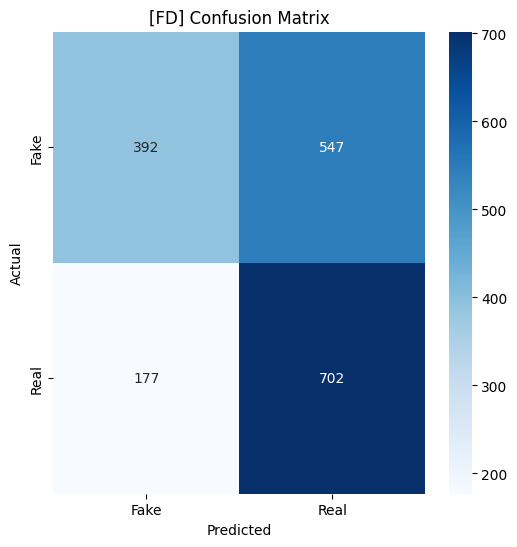

(0.6017601760176018,
 0.6782613120486176,
 np.float64(0.39194989950095777),
 np.float64(0.6597744360902256))

In [ ]:
"""
Training and evaluating the Frequency domain only model
"""
print("\nTraining Frequency Domain only model")
fd_model = FDBranchModel().to(DEVICE)
opt_fd = torch.optim.Adam(fd_model.parameters(), lr=1e-4, weight_decay=1e-4)
sch_fd = torch.optim.lr_scheduler.CosineAnnealingLR(opt_fd, T_max=50)

train_single_input(
    model=fd_model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=opt_fd,
    scheduler=sch_fd,
    device=DEVICE,
    MODEL_SAVE_PATH="/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/kova02_fd_only.pth",
    epochs=50,
    patience=5,
    input_kind="fd",
)

print("\nEvaluating Frequency Domain only model on Test Dataset:")
evaluate_single_input(fd_model, test_loader, DEVICE, input_kind="fd")


Training Spatial-only (Swin) model:


[SPATIAL] Epoch 1/50: 100%|██████████| 529/529 [07:10<00:00,  1.23it/s]


[SPATIAL] Epoch 1: Train Loss 0.6169 | Train Acc 0.6454 | Test Loss 0.3997 | Test Acc 0.8295


[SPATIAL] Epoch 2/50: 100%|██████████| 529/529 [07:24<00:00,  1.19it/s]


[SPATIAL] Epoch 2: Train Loss 0.2981 | Train Acc 0.8789 | Test Loss 0.2200 | Test Acc 0.9202


...

[SPATIAL] Epoch 9: Train Loss 0.3224 | Train Acc 0.8610 | Test Loss 0.3198 | Test Acc 0.8641


[SPATIAL] Epoch 10/50: 100%|██████████| 529/529 [06:52<00:00,  1.28it/s]


[SPATIAL] Epoch 10: Train Loss 0.3040 | Train Acc 0.8710 | Test Loss 0.2876 | Test Acc 0.8773
[SPATIAL] Early stopping at epoch 10

Evaluating Spatial-only (Swin) model on Test Dataset:


Evaluating (spatial): 100%|██████████| 57/57 [00:31<00:00,  1.81it/s]


[SPATIAL] Test Accuracy: 88.01%
[SPATIAL] AUC-ROC: 0.9597, EER: 0.1218, F1-Score: 0.8687
              precision    recall  f1-score   support

        Fake       0.85      0.94      0.89       939
        Real       0.92      0.82      0.87       879

    accuracy                           0.88      1818
   macro avg       0.89      0.88      0.88      1818
weighted avg       0.88      0.88      0.88      1818



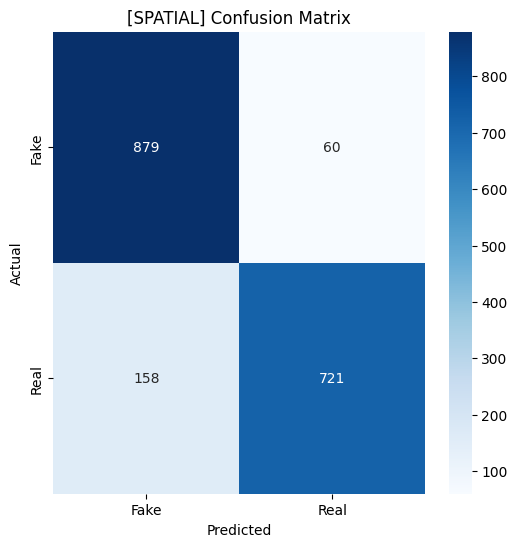

(0.8800880088008801,
 0.9596671113098072,
 np.float64(0.12182373958208391),
 np.float64(0.8686746987951808))

In [ ]:
"""
Training and evaluating the Spatial domain only (By SWIN transformer) model 
"""
print("\nTraining Spatial Domain only model")
sp_model = SpatialBranchModel().to(DEVICE)
opt_sp = torch.optim.Adam(sp_model.parameters(), lr=1e-4, weight_decay=1e-4)
sch_sp = torch.optim.lr_scheduler.CosineAnnealingLR(opt_sp, T_max=50)

train_single_input(
    model=sp_model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=opt_sp,
    scheduler=sch_sp,
    device=DEVICE,
    MODEL_SAVE_PATH="/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/kova02_spatial_only.pth",
    epochs=50,
    patience=5,
    input_kind="spatial",
)

print("\nEvaluating Spatial domain only model with Test Dataset")
evaluate_single_input(sp_model, test_loader, DEVICE, input_kind="spatial")

# Few-shot Learning Model

In [32]:
class FewShotSampler:
    def __init__(self, dataset, n_way=2, k_shot=1, k_query=15):
        self.dataset = dataset
        self.n_way = n_way
        self.k_shot = k_shot
        self.k_query = k_query

        # class: 0 = Fake, 1 = Real
        self.class_to_indices = {0: [], 1: []}
        for index, (_, _, label) in enumerate(dataset):
            lbl = int(label.item())
            if lbl in self.class_to_indices:
                self.class_to_indices[lbl].append(index)

    def sample_episode(self):
        support_set = []
        query_set = []
        for label in [0, 1]:
            indices = self.class_to_indices[label]
            total_needed = self.k_shot + self.k_query
            if len(indices) < total_needed:
                raise ValueError(f"Not enough samples in class {label}, Add some samples.")

            # Shuffle and randomly select
            selected_indices = random.sample(indices, total_needed)
            random.shuffle(selected_indices)

            support_indices = selected_indices[:self.k_shot]
            query_indices = selected_indices[self.k_shot:]

            for index in support_indices:
                item = self.dataset[index]
                support_set.append((item[0], item[1], torch.tensor(label)))

            for index in query_indices:
                item = self.dataset[index]
                query_set.append((item[0], item[1], torch.tensor(label)))

        return support_set, query_set

In [34]:
""" 
Evaluating the few shot learning with frozen weights. 
"""

def evaluate_few_shot_frozen(model, sampler, device, n_way=2, k_shot=1, k_query=15, num_episodes=600):
    model.eval()
    accuracies = []

    with torch.no_grad():
        for _ in tqdm(range(num_episodes), desc="Evaluating Few-Shot Episodes"):
            support_set, query_set = sampler.sample_episode()

            # Support features extraction
            support_features = []
            support_labels = []
            for sp_img, fd_img, label in support_set:
                sp_img = sp_img.unsqueeze(0).to(device)
                fd_img = fd_img.unsqueeze(0).to(device)

                # Frozen model forward pass
                fd_features = model.fd_branch(fd_img)
                sp_features = model.spatial_branch(sp_img)
                fused_features, _ = model.fusion(
                    fd_features, sp_features) 
                support_features.append(fused_features.cpu().numpy())
                support_labels.append(label.item())

            support_features = np.concatenate(support_features)  
            support_labels = np.array(support_labels)

            # Calculating protypes for each class
            prototypes = []
            for classes in range(n_way):
                mask = (support_labels == classes)
                if mask.sum() == 0:
                    continue
                prototype = support_features[mask].mean(axis=0)
                prototypes.append(prototype)
            prototypes = np.stack(prototypes)  

            #Query features extraction
            query_features = []
            query_labels = []
            for sp_img, fd_img, label in query_set:
                sp_img = sp_img.unsqueeze(0).to(device)
                fd_img = fd_img.unsqueeze(0).to(device)

                fd_features = model.fd_branch(fd_img)
                sp_features = model.spatial_branch(sp_img)
                fused_features, _ = model.fusion(fd_features, sp_features)
                query_features.append(fused_features.cpu().numpy())
                query_labels.append(label.item())

            query_features = np.concatenate(query_features)  # (N*Q, 128)
            query_labels = np.array(query_labels)

            # Prediction by calculating euclidean distance of prototypes
            dists = np.linalg.norm(
                query_features[:, None] - prototypes[None, :], axis=2) ** 2
            predictions = np.argmin(dists, axis=1)

            # Mapping the labels
            accuracy = accuracy_score(query_labels, predictions)
            accuracies.append(accuracy)

    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)
    ci_95 = 1.96 * std_accuracy / np.sqrt(num_episodes)

    print(f"\n Evaluation of Few-Shot Learning with frozen weights")
    print(f"Task -  {n_way} way, {k_shot} shot")
    print(f"Accuracy - {mean_accuracy*100:.2f}% ± {ci_95*100:.2f}% (95% CI)")
    return mean_accuracy, std_accuracy, ci_95

In [ ]:
""" 
function for the execution of Few Shot Learning on given dataset
    test_data_path - path to the test dataset
    df_name - name of the dataset
"""

def few_shot_setting_experiment(test_data_path, df_name):
    BATCH_SIZE = 32
    # Setting up GPU
    if torch.backends.mps.is_available():
        DEVICE = torch.device("mps")
    else:
        DEVICE = torch.device("cpu")

    # Spatial Transformation
    spatial_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomCrop(224, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[
                             0.229, 0.224, 0.225])
    ])

    # Frequency domain transformation
    fd_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[
                             0.229, 0.224, 0.225])
    ])
    test_dataset = DeepfakeDataset(
        test_data_path, spatial_transform=spatial_transform, fd_transform=fd_transform)
    
    # Model Initialisation
    model = TwoBranchModel(use_cross_attention=True)
    model.load_state_dict(torch.load(
        "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/kova02_cross_13_8.pth"))
    model.to(DEVICE)
    model.eval()

    # Freeze
    for param in model.parameters():
        param.requires_grad = False

    print("Model loaded and frozen.")

    # Defining few-shot setting
    N_WAY = 2
    K_SHOT = 1  
    K_QUERY = 15
    NUM_EPISODES = 600

    # Sampler initialisation
    test_sampler = FewShotSampler(
        test_dataset, n_way=N_WAY, k_shot=K_SHOT, k_query=K_QUERY)

    # Evaluation
    print(
        f"\nEvaluating {N_WAY}-way {K_SHOT}-shot with {NUM_EPISODES} episodes on {df_name} Dataset...")
    evaluate_few_shot_frozen(
        model, test_sampler, DEVICE,
        n_way=N_WAY, k_shot=K_SHOT, k_query=K_QUERY, num_episodes=NUM_EPISODES
    )

    # 5-shot
    print(f"\nNow evaluating 5-shot on {df_name} Dataset...")
    test_sampler_5shot = FewShotSampler(
        test_dataset, n_way=2, k_shot=5, k_query=15)
    evaluate_few_shot_frozen(
        model, test_sampler_5shot, DEVICE,
        n_way=2, k_shot=5, k_query=15, num_episodes=600
    )

    # 10-shot
    print(f"\nNow evaluating 10-shot on {df_name} Dataset...")
    test_sampler_5shot = FewShotSampler(
        test_dataset, n_way=2, k_shot=10, k_query=15)
    evaluate_few_shot_frozen(
        model, test_sampler_5shot, DEVICE,
        n_way=2, k_shot=10, k_query=15, num_episodes=600
    )

    # 20-shot
    print(f"\nNow evaluating 20-shot on {df_name} Dataset...")
    test_sampler_5shot = FewShotSampler(
        test_dataset, n_way=2, k_shot=20, k_query=15)
    evaluate_few_shot_frozen(
        model, test_sampler_5shot, DEVICE,
        n_way=2, k_shot=20, k_query=15, num_episodes=600
    )

In [ ]:
""" 
Few shot learning experiment on DFDC (in-domain) dataset
"""
few_shot_setting_experiment(
    "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/test_frames_modified", "DFDC")

Class-to-index mapping for /Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFDC_trained: {'fake': 0, 'real': 1}
Class-to-index mapping for /Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/test_frames_modified: {'fake': 0, 'real': 1}


/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded and frozen.

Evaluating 2-way 1-shot with 600 episodes...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [4:02:49<00:00, 24.28s/it]    



=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 1-shot
Accuracy: 91.13% ± 1.03% (95% CI)

Now evaluating 5-shot...


...


=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 5-shot
Accuracy: 94.63% ± 0.33% (95% CI)

Now evaluating 10-shot...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [15:45<00:00,  1.58s/it]



=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 10-shot
Accuracy: 94.97% ± 0.31% (95% CI)

Now evaluating 20-shot...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [21:32<00:00,  2.15s/it]


=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 20-shot
Accuracy: 94.62% ± 0.32% (95% CI)


# Evaluating on CDF Dataset

In [ ]:
""" 
Few shot learning experiment on CDF dataset
"""
few_shot_setting_experiment(
    "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/CDF_test_frame", "CDF")

Class-to-index mapping for /Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/CDF_test_frame: {'fake': 0, 'real': 1}


/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded and frozen.

Evaluating 2-way 1-shot with 600 episodes on CDF Dataset...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [10:42<00:00,  1.07s/it]



=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 1-shot
Accuracy: 59.70% ± 1.35% (95% CI)

Now evaluating 5-shot on CDF Dataset...


...


=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 5-shot
Accuracy: 66.44% ± 0.93% (95% CI)

Now evaluating 10-shot on CDF Dataset...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [16:23<00:00,  1.64s/it]



=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 10-shot
Accuracy: 68.98% ± 0.66% (95% CI)

Now evaluating 20-shot on CDF Dataset...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [22:58<00:00,  2.30s/it]


=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 20-shot
Accuracy: 70.16% ± 0.57% (95% CI)


# Evaluation on DFW Dataset

In [ ]:
""" 
Few shot learning experiment on DFW dataset
"""
few_shot_setting_experiment(
    "/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFW_test_frame", "DFW")

Class-to-index mapping for /Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/DFW_test_frame: {'fake': 0, 'real': 1}


/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/kovarthanan/Acedamic/City, University of London/Research/DFDC/test/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded and frozen.

Evaluating 2-way 1-shot with 600 episodes on DFW Dataset...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [15:29<00:00,  1.55s/it]



=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 1-shot
Accuracy: 50.52% ± 0.89% (95% CI)

Now evaluating 5-shot on DFW Dataset...


...


=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 5-shot
Accuracy: 52.42% ± 0.86% (95% CI)

Now evaluating 10-shot on DFW Dataset...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [23:46<00:00,  2.38s/it]



=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 10-shot
Accuracy: 54.85% ± 0.79% (95% CI)

Now evaluating 20-shot on DFW Dataset...


Evaluating Few-Shot Episodes: 100%|██████████| 600/600 [32:48<00:00,  3.28s/it]


=== Few-Shot Evaluation (Frozen Model) ===
Task: 2-way, 20-shot
Accuracy: 55.94% ± 0.74% (95% CI)
